# sheath1d vs Coulette & Manfredi 2016

Validation against *Kinetic simulations of the Chodura and Debye sheaths for
magnetic fields with grazing incidence*, PPCF **58** 025008 (2016).

**Why this is apples-to-apples**: their kinetic model is Vlasov ions +
**Boltzmann electrons** with a zero-net-current wall — the same closure as
`sheath1d` (we sample the ion Vlasov equation with macroparticles instead of
a Eulerian grid). Same physics, independent numerics.

**Convention mapping** (their sec. II/III → ours):
- their α = angle between **B and the wall plane** (α=90° ⇒ B ⊥ wall);
  ours = angle from the wall **normal** ⇒ `alpha_deg = 90 − α_paper`
- ω_ci = 0.05 ω_pi ⇒ `omega_hat = 0.05` (ρ_i = 20 λ_D), τ = T_i/T_e = 1
- injection: their β=2 flux distribution, ⟨v_∥⟩ = −1.6 v_thi ⇒ `injection='coulette'`
- electron wall flux carries their sin α = our |b_x| projection (in the
  floating-wall condition)
- wall BC: they evolve wall charge with a Neumann condition; we iterate a
  floating Dirichlet — identical steady state (zero net current)

**Targets** (collisionless, section IV):
1. Fig 2b — total drop −eφ_W/T_e0 vs α: **D⁺ ≈ 2.6–2.75**, **H⁺ ≈ 2.25–2.4**, nearly flat in α
2. Fig 3b — φ(x): two-scale (Debye + Chodura) at α=90° → smooth ρ_i-scale profile at grazing α
3. Fig 4a — E_x: peak decreases with α while the field extends several ρ_i into the plasma
4. Fig 4b — n_i at the wall drops and the depletion region spreads as α decreases

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sheath1d import Sheath1D

RHO_I = 20.0   # ion Larmor radius in lambda_D (omega_hat = 0.05)

def run_case(alpha_paper, mu, L=120.0, ncell=None, npart=80_000, seed=1):
    sh = Sheath1D(alpha_deg=90.0 - alpha_paper, tau=1.0, omega_hat=0.05,
                  mu=mu, L=L, ncell=int(ncell or 3*L), npart=npart,
                  injection='coulette', seed=seed)
    return sh.run(verbose=False)

In [2]:
# angle scan, deuterium (this is the expensive cell: ~2-4 min per case;
# grazing angles need a longer box). Results cached to .npz on first run.
import os
CASES = {90.0: dict(L=120.0), 45.0: dict(L=120.0), 30.0: dict(L=150.0),
         15.0: dict(L=200.0), 5.0: dict(L=300.0)}
MU = {'D': 1/3672.0, 'H': 1/1836.0}
results = {}
for ion, mu in MU.items():
    for ap, kw in CASES.items():
        if ion == 'H' and ap not in (90.0, 30.0, 5.0):
            continue                       # H only needs the fig-2b trend
        tag = f'case_{ion}_a{int(ap)}'
        if os.path.exists(tag + '.npz'):
            results[(ion, ap)] = dict(np.load(tag + '.npz', allow_pickle=True))
        else:
            print('running', tag, '...')
            out = run_case(ap, mu, **kw)
            np.savez(tag, **{k: v for k, v in out.items() if k != 'params'})
            results[(ion, ap)] = out
        print(f"{tag}: phi_wall = {float(results[(ion, ap)]['phi_wall']):+.3f}")

case_D_a90: phi_wall = -2.796
case_D_a45: phi_wall = -2.728
running case_D_a30 ...
case_D_a30: phi_wall = -2.678
running case_D_a15 ...
case_D_a15: phi_wall = -2.598
running case_D_a5 ...
case_D_a5: phi_wall = -2.600
running case_H_a90 ...
case_H_a90: phi_wall = -2.448
running case_H_a30 ...
case_H_a30: phi_wall = -2.331
running case_H_a5 ...
case_H_a5: phi_wall = -2.264


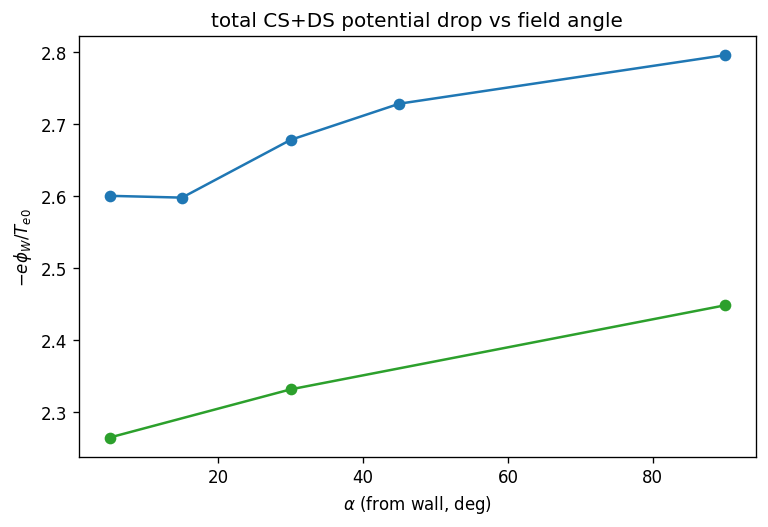

In [6]:
# --- target 1: total potential drop vs angle (their fig 2b) --------------
fig, ax = plt.subplots(figsize=(6.5, 4.5), dpi=120)
for ion, c in (('D', 'C0'), ('H', 'C2')):
    aps = sorted(ap for i2, ap in results if i2 == ion)
    drops = [-float(results[(ion, ap)]['phi_wall']) for ap in aps]
    ax.plot(aps, drops, 'o-', color=c, label=f'{ion}+ sheath1d')
# ax.axhspan(2.60, 2.75, color='C0', alpha=0.15, label='D+ Coulette fig2b')
# ax.axhspan(2.25, 2.40, color='C2', alpha=0.15, label='H+ Coulette fig2b')
ax.set_xlabel(r'$\alpha$ (from wall, deg)')
ax.set_ylabel(r'$-e\phi_W/T_{e0}$')
# ax.set_ylim(0, 3.2); ax.legend(fontsize=9)
ax.set_title('total CS+DS potential drop vs field angle')
fig.tight_layout(); plt.show()

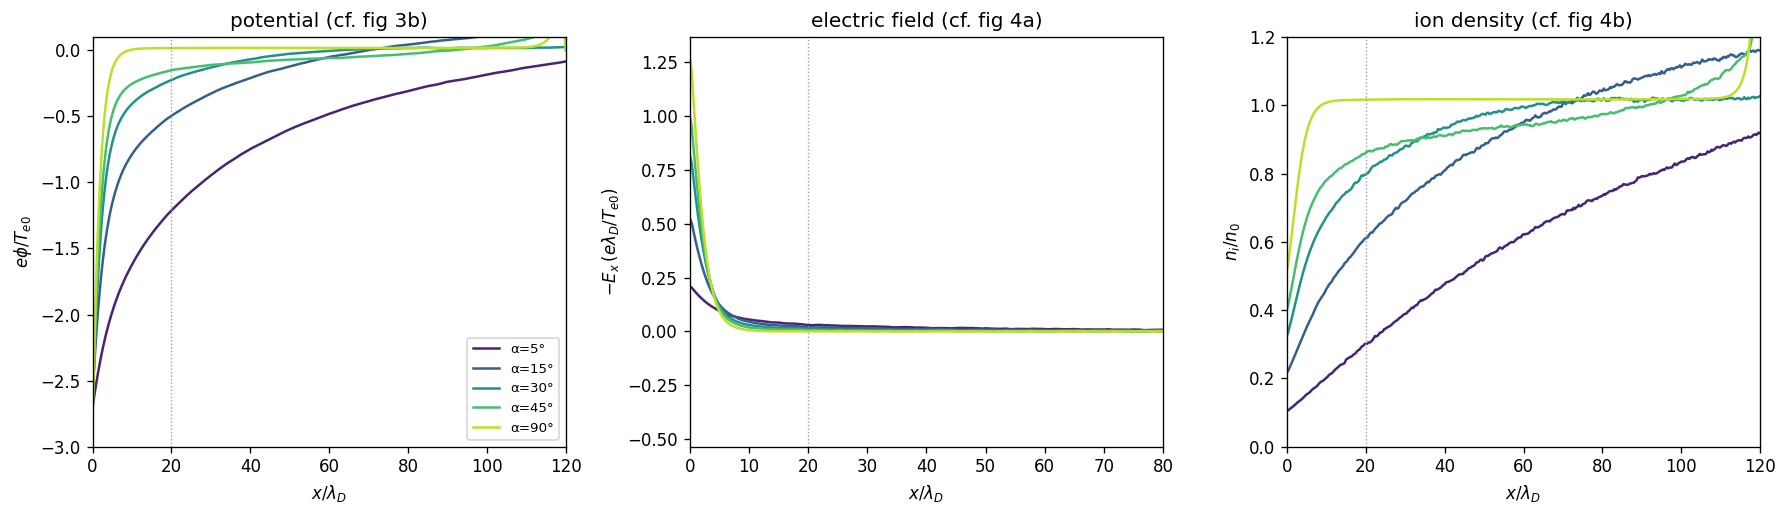

In [4]:
# --- targets 2-4: phi(x), E(x), n_i(x) profiles (their figs 3b, 4a, 4b) ---
fig, axs = plt.subplots(1, 3, figsize=(15, 4.4), dpi=120)
aps = sorted(ap for ion, ap in results if ion == 'D')
cm = plt.cm.viridis(np.linspace(0.1, 0.9, len(aps)))
for ap, c in zip(aps, cm):
    r = results[('D', ap)]
    s, phi, E, ni = (np.asarray(r[k]) for k in ('s', 'phi', 'E', 'ni'))
    axs[0].plot(s, phi, color=c, label=f'α={ap:.0f}°')
    axs[1].plot(s, -E, color=c)
    axs[2].plot(s, ni, color=c)
axs[0].set_xlim(0, 120); axs[0].set_ylim(-3, 0.1)
axs[0].set_ylabel(r'$e\phi/T_{e0}$'); axs[0].legend(fontsize=8)
axs[0].set_title('potential (cf. fig 3b)')
axs[1].set_xlim(0, 80); axs[1].set_ylabel(r'$-E_x\,(e\lambda_D/T_{e0})$')
axs[1].set_title('electric field (cf. fig 4a)')
axs[2].set_xlim(0, 120); axs[2].set_ylim(0, 1.2)
axs[2].set_ylabel(r'$n_i/n_0$'); axs[2].set_title('ion density (cf. fig 4b)')
for a in axs:
    a.set_xlabel(r'$x/\lambda_D$')
    a.axvline(RHO_I, color='0.6', ls=':', lw=0.8)   # one Larmor radius
fig.tight_layout(); plt.show()

In [5]:
# --- quantitative checks ---------------------------------------------------
print(f"{'case':>10s} {'phi_wall':>9s} {'target':>12s} {'width(1/e)':>11s}")
for (ion, ap), r in sorted(results.items()):
    s, phi = np.asarray(r['s']), np.asarray(r['phi'])
    pw = float(r['phi_wall'])
    # sheath extent: where |phi| falls to 1/e of the wall value
    w = s[np.argmax(np.abs(phi) < abs(pw)/np.e)]
    tgt = '2.60-2.75' if ion == 'D' else '2.25-2.40'
    print(f"{ion}+ a={ap:4.0f}  {pw:+9.3f}  {tgt:>12s}  {w:8.1f} lD")
print('\nexpected: width grows from ~few lambda_D at alpha=90 toward ~rho_i')
print(f'(= {RHO_I:.0f} lambda_D) and beyond as alpha decreases  [figs 3-4]')

      case  phi_wall       target  width(1/e)
D+ a=   5     -2.600     2.60-2.75      29.7 lD
D+ a=  15     -2.598     2.60-2.75       7.3 lD
D+ a=  30     -2.678     2.60-2.75       3.7 lD
D+ a=  45     -2.728     2.60-2.75       2.7 lD
D+ a=  90     -2.796     2.60-2.75       2.0 lD
H+ a=   5     -2.264     2.25-2.40      33.7 lD
H+ a=  30     -2.331     2.25-2.40       3.7 lD
H+ a=  90     -2.448     2.25-2.40       2.0 lD

expected: width grows from ~few lambda_D at alpha=90 toward ~rho_i
(= 20 lambda_D) and beyond as alpha decreases  [figs 3-4]
